# This is heart disease project
we are going to predict based on data wheather someone have the heart disease or not?
### 1- Problem Definaion
### 2- Data
### 3- Evaluate 
### 4- Feature
### 5- Modeling
### 6- Experimentation


# 1- Problem Defination 
> Based on given data we need to predict if a patient has heart disease or not?


# 2- Data
> we have data and should load

# 3- Evaluate
> in initial stage we need to make sure, if our models gives us the accuracy of 95%

# 4- Features
> what features are import, what features columns means what?
> 
age>40-95

anaemia>(0=no,1=yes)

creatinine_phosphokinase>23-7861

diabetes>(0=no,1=yes)

ejection_fraction>14-80

high_blood_pressure>(0=no,1=yes)

platelets>25.1k-850k

serum_creatinine>0.5-9.4

serum_sodium>113-148

sex>(0=no,1=yes)



# Tools Preperation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
# Importing Models of SK Learn.....
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
# Import Evaluation Liabraries......
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import roc_curve

# Exploring the data initial stage
1-                          what problem i am going to solve
2-                          what kind of data i have 
3-                          does this data have missing values
4-                          are there any outliers,sporious vector
5-                          can we add or remove some of features

In [2]:
df = pd.read_csv('heart_failure_clinical_records_dataset (1).csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
df['DEATH_EVENT'].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [4]:
df.isna().sum() # are there any missing value

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [5]:
df['sex'].value_counts()

sex
1    194
0    105
Name: count, dtype: int64

In [6]:
pd.crosstab(df.DEATH_EVENT,df.sex)

sex,0,1
DEATH_EVENT,,
0,71,132
1,34,62


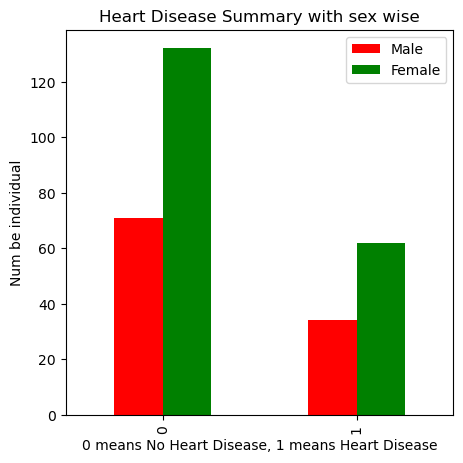

In [7]:
pd.crosstab(df.DEATH_EVENT,df.sex).plot(kind = 'bar',
                                        figsize=(5,5),
                                        color=['red','green'])
plt.title('Heart Disease Summary with sex wise')
plt.xlabel('0 means No Heart Disease, 1 means Heart Disease')
plt.ylabel('Num be individual')
plt.legend(['Male','Female'])
plt.show()


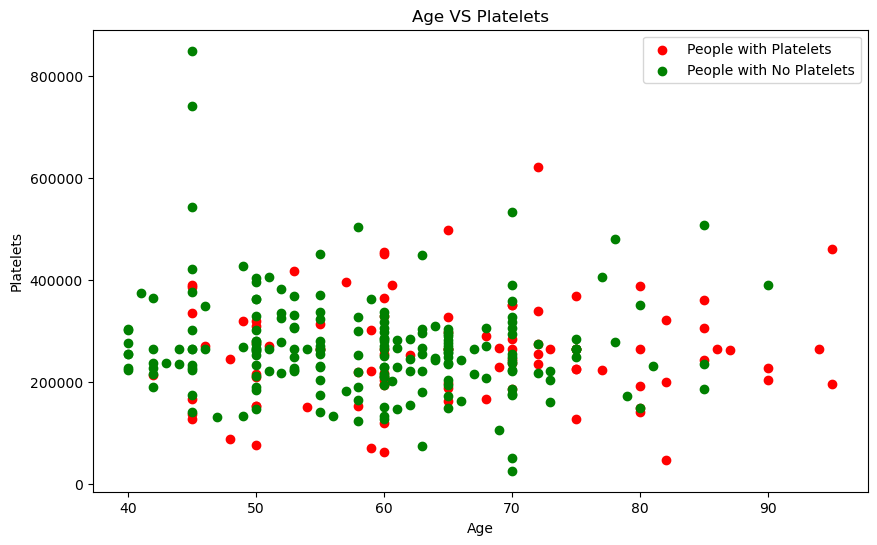

In [8]:
# Finding Pattrens in Data Using Scatter plot
plt.figure(figsize=(10,6))
# Create Scatter Plot
plt.scatter(df.age[df.DEATH_EVENT==1],df.platelets[df.DEATH_EVENT==1],c='red')
plt.scatter(df.age[df.DEATH_EVENT==0],df.platelets[df.DEATH_EVENT==0],c='green')
plt.title('Age VS Platelets')
plt.xlabel('Age')
plt.ylabel('Platelets')
plt.legend(['People with Platelets','People with No Platelets'])

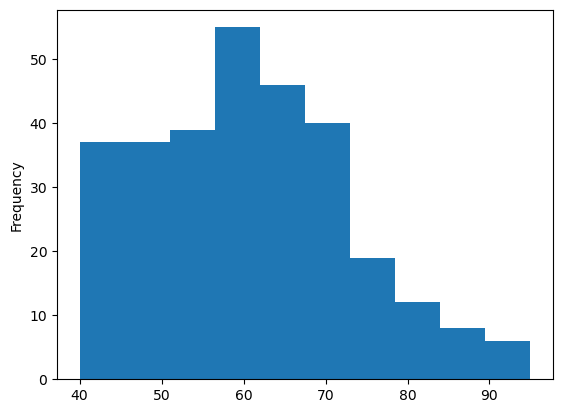

In [9]:
# Create Histogram to see the Distribution
df.age.plot.hist();

In [10]:
df.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,-0.224068,0.253729
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,-0.141414,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,-0.009346,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,0.033726,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,0.041729,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,-0.196439,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,0.010514,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,-0.149315,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,0.087640,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.015608,-0.004316


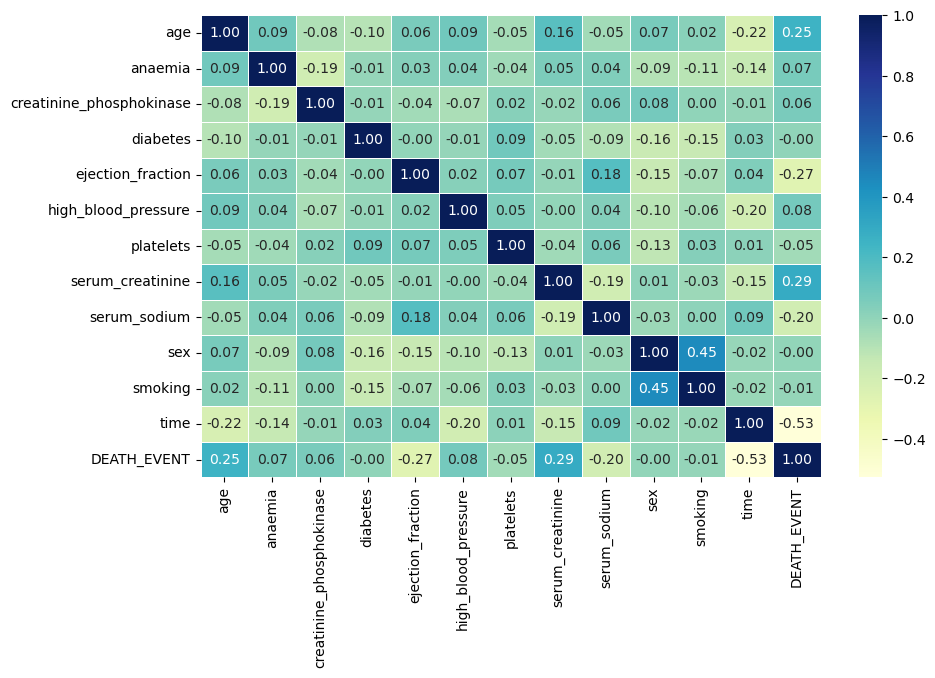

In [11]:
# Lets draw correlation map
cor_map = df.corr()
fig,ax = plt.subplots(figsize=(10,6))
ax = sns.heatmap(cor_map,
                annot=True,
                linewidths=0.5,
                fmt='0.2f',
                cmap='YlGnBu');

# 5-Modeling

In [12]:
# Split data into test and train
X = df.drop('DEATH_EVENT',axis=1)
y = df['DEATH_EVENT']
# using random seed,so the result will produced same no change
np.random.seed(1)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

# The Models we are going to use
1. K-Nearest Neighbors Classifier
2. Random Forest Classifier
3. Logistic Regression

In [13]:
# Putting models into dictioneries
models = {'KNN':KNeighborsClassifier(),
          'RFC':RandomForestClassifier(),
          'LR':LogisticRegression()}
# Create function to evaluate model
def fit_and_score(models,X_train,X_test,y_train,y_test):
    np.random.seed(1)
    # make dictionary to score the model
    model_score={}
    # Looping through
    for name,model in models.items():
        model.fit(X_train,y_train)
        # Evaluate the model and append it score
        model_score[name] = model.score(X_test,y_test)
        
    return model_score
    

In [14]:
model_scores = fit_and_score(models=models,
                            X_train=X_train,
                            X_test=X_test,
                            y_train=y_train,
                            y_test=y_test)
model_scores

C:\Users\me\Desktop\cardio_med\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.6333333333333333,
 'RFC': 0.9333333333333333,
 'LR': 0.8666666666666667}

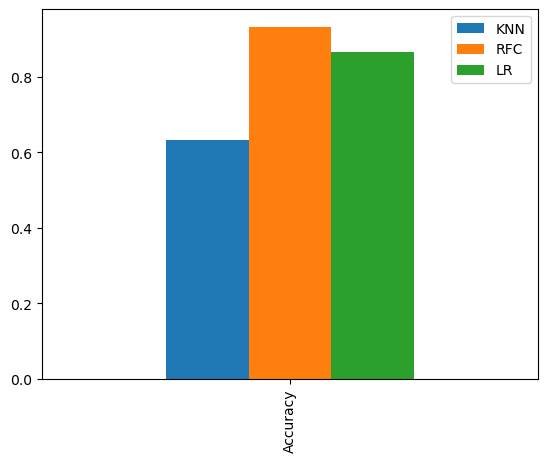

In [15]:
model_compare = pd.DataFrame(model_scores,index=['Accuracy'])
model_compare.plot(kind='bar');

# Moving and Tunning the Model
Universal Method use for every classificaion problem
* Hyperparameter Tunning
* Features Improving
* Confusion_matrix
* Cross_Validation
* Precision
* Recall
* f1_Score
* Classification Report
* ROC Curve
                     

In [16]:
KNN = KNeighborsClassifier()
KNN.set_params()

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [17]:
train_score = []
test_score = []
# Create range to be best use for n_neighbors
nneighbors = range(1,30)
#KNN Instance
KNN =KNeighborsClassifier()
#Looping through the range
for i in nneighbors:
    KNN.set_params(n_neighbors=i)
    # Run the fit for i-th value
    KNN.fit(X_train,y_train)
    #Update the training Score
    train_score.append(KNN.score(X_train,y_train))
    #Update test Score list
    test_score.append(KNN.score(X_test,y_test))

    

In [18]:
train_score

[1.0,
 0.7782426778242678,
 0.7782426778242678,
 0.7112970711297071,
 0.7196652719665272,
 0.694560669456067,
 0.702928870292887,
 0.6903765690376569,
 0.7071129707112971,
 0.698744769874477,
 0.702928870292887,
 0.6736401673640168,
 0.6778242677824268,
 0.6820083682008368,
 0.698744769874477,
 0.6778242677824268,
 0.6820083682008368,
 0.6569037656903766,
 0.6652719665271967,
 0.6610878661087866,
 0.6610878661087866,
 0.6610878661087866,
 0.6694560669456067,
 0.6610878661087866,
 0.6569037656903766,
 0.6569037656903766,
 0.6569037656903766,
 0.6485355648535565,
 0.6569037656903766]

In [19]:
test_score

[0.5166666666666667,
 0.6833333333333333,
 0.6166666666666667,
 0.7,
 0.6333333333333333,
 0.6666666666666666,
 0.6333333333333333,
 0.6833333333333333,
 0.6833333333333333,
 0.6833333333333333,
 0.6666666666666666,
 0.7166666666666667,
 0.6666666666666666,
 0.7333333333333333,
 0.7,
 0.7333333333333333,
 0.7333333333333333,
 0.75,
 0.75,
 0.75,
 0.75,
 0.75,
 0.7333333333333333,
 0.75,
 0.7333333333333333,
 0.7666666666666667,
 0.75,
 0.7666666666666667,
 0.7333333333333333]

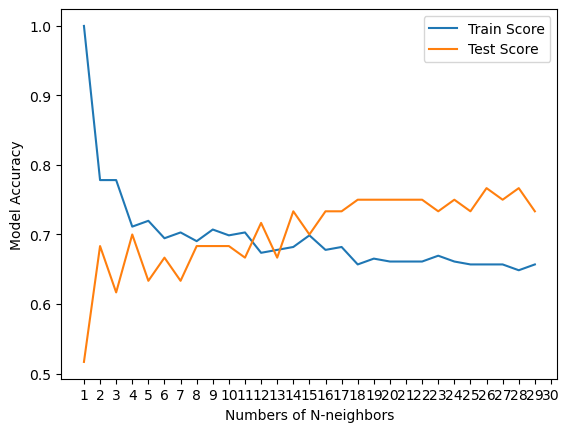

In [20]:
# plot the Accuracy score
plt.plot(nneighbors,train_score,label='Train Score')
plt.plot(nneighbors,test_score,label='Test Score')
plt.xticks(np.arange(1,31,1))
plt.xlabel('Numbers of N-neighbors')
plt.ylabel('Model Accuracy')
plt.legend();